# Second Order Cone Programming

The problem:
$$\max_w \ \mu^Tw \quad \text{s.t.} \quad w^T\Sigma w \leq \sigma_{\max}^2, \ \ \mathbf{1}^Tw = 1$$

QP allows a quadratic *objective* but requires *linear constraints*. Here the objective is linear and the constraint is quadratic — that's the mirror image, and it's a different problem class. A quadratic inequality constraint puts you in **Quadratically Constrained Quadratic Programming (QCQP)**, and because $\Sigma \succeq 0$ this particular QCQP is convex — which means it can be reformulated as a **Second-Order Cone Program (SOCP)**.

The **second-order cone** (also called the Lorentz cone or "ice-cream cone") in $\mathbb{R}^{n+1}$ is the set:

$$
\mathcal{Q} = \left\{ (t, x) \ : \ \|x\|_2 \leq t \right\}
$$

where $x \in \mathbb{R}^n$, $t \in \mathbb{R}$, and $\|x\|_2 = \sqrt{x_1^2 + \cdots + x_n^2}$ is the ordinary Euclidean norm. In words: all the points where a scalar $t$ is at least the length of a vector $x$.

Picture $n=2$, so you're in 3D with axes $(t, x_1, x_2)$. The condition $\sqrt{x_1^2 + x_2^2} \leq t$ carves out a solid cone opening upward along the $t$-axis — circular cross-sections of radius $t$ at height $t $. That's literally an ice-cream cone standing on its point at the origin.

The cone is a convex set — the segment between any two points in it stays inside (the norm is convex, so the sublevel set $\|x\| \le t$ is convex). This is what makes optimizing over it tractable.

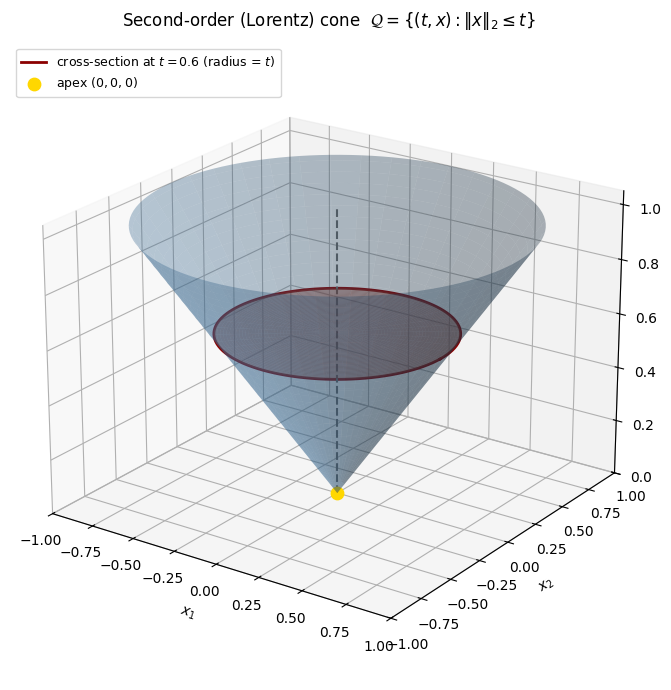

In [1]:
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Parametrize the cone surface: at height t, radius = t
theta = np.linspace(0, 2 * np.pi, 120)
t_vals = np.linspace(0, 1, 60)
THETA, T = np.meshgrid(theta, t_vals)

X1 = T * np.cos(THETA)   # x₁ = t·cos θ
X2 = T * np.sin(THETA)   # x₂ = t·sin θ

ax.plot_surface(X1, X2, T, alpha=0.35, color="steelblue", linewidth=0, antialiased=True)

# Highlight a cross-sectional disk at t = 0.6
t_slice = 0.6
r_slice = np.linspace(0, t_slice, 40)
THETA_d, R_d = np.meshgrid(theta, r_slice)
ax.plot_surface(R_d * np.cos(THETA_d), R_d * np.sin(THETA_d),
                np.full_like(R_d, t_slice), alpha=0.5, color="tomato", linewidth=0)
ax.plot(t_slice * np.cos(theta), t_slice * np.sin(theta),
        np.full_like(theta, t_slice), color="darkred", lw=2,
        label=r"cross-section at $t=0.6$ (radius = $t$)")

# Apex
ax.scatter([0], [0], [0], color="gold", s=80, zorder=5, label="apex $(0,0,0)$")

# t-axis spine
ax.plot([0, 0], [0, 0], [0, 1.05], color="dimgray", lw=1.5, ls="--")

ax.set_xlabel(r"$x_1$", labelpad=6)
ax.set_ylabel(r"$x_2$", labelpad=6)
ax.set_zlabel(r"$t$", labelpad=6)
ax.set_title(r"Second-order (Lorentz) cone  $\mathcal{Q} = \{(t,x) : \|x\|_2 \leq t\}$",
             fontsize=12, pad=12)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(0, 1.05)
ax.view_init(elev=22, azim=-55)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


**Why this matters and why it's the practitioner's favorite.** The reason this formulation dominates in practice over the $\gamma$-utility QP is *interpretability of the constraint*. With the utility form $\max \mu^Tw - \frac{\gamma}{2}w^T\Sigma w$, you tune an abstract risk-aversion $\gamma$ that has no units anyone can feel. With the SOCP form, you set $\sigma_{\max}$ directly — "I want at most 12% annualized volatility." A portfolio manager, a risk committee, a mandate document can all speak in terms of a volatility cap; nobody can speak in terms of $\gamma$. So the SOCP formulation lets you impose the risk limit *as the actual business constraint it is*, rather than backing into it by trial-and-error on $\gamma$.

In [2]:
mu = np.array(
    [0.0720, 0.1552, 0.1754, 0.0898, 0.4290, 0.3929, 0.3217, 0.1838]
)
sigma = np.array([
    [0.0946, 0.0374, 0.0349, 0.0348, 0.0542, 0.0368, 0.0321, 0.0327],
    [0.0374, 0.0775, 0.0387, 0.0367, 0.0382, 0.0363, 0.0356, 0.0342],
    [0.0349, 0.0387, 0.0624, 0.0336, 0.0395, 0.0369, 0.0338, 0.0243],
    [0.0348, 0.0367, 0.0336, 0.0682, 0.0402, 0.0335, 0.0436, 0.0371],
    [0.0542, 0.0382, 0.0395, 0.0402, 0.1724, 0.0789, 0.0700, 0.0501],
    [0.0368, 0.0363, 0.0369, 0.0335, 0.0789, 0.0909, 0.0536, 0.0449],
    [0.0321, 0.0356, 0.0338, 0.0436, 0.0700, 0.0536, 0.0965, 0.0442],
    [0.0327, 0.0342, 0.0243, 0.0371, 0.0501, 0.0449, 0.0442, 0.0816]
])

The trick is to recognize that the left side of $w^T\Sigma w \leq \sigma_{\max}^2$ is a squared norm, so taking square roots turns it into a norm constraint — which is exactly the shape of a second-order cone.

**Step 1 — factor the covariance.** Since $\Sigma \succeq 0$, it has a "square root." The cleanest is the Cholesky factor: $\Sigma = LL^T$ with $L$ lower triangular. Then:
$$w^T\Sigma w = w^T L L^T w = (L^T w)^T (L^T w) = \|L^T w\|_2^2​$$
So portfolio *variance* is the squared Euclidean norm of the vector $L^T w$. That vector $L^T w$ is worth pausing on — it's the portfolio's risk expressed in the "whitened" coordinates where the assets are uncorrelated and unit-variance (the same decorrelation idea as PCA/Cholesky from before). Its length *is* the portfolio volatility.

**Step 2 — take square roots.** The variance cap becomes:

$$
⁡w^T\Sigma w \leq \sigma_{\max}^2 \iff \|L^T w\|_2^2 \leq \sigma_{\max}^2 \iff \|L^T w\|_2 \leq \sigma_{\max}
$$

That last form — a Euclidean norm of an affine function of $w$ bounded by a constant — **is a second-order cone constraint.** Matching it to the cone $\mathcal{Q} = \{(t, x) : \|x\|_2 \leq t\}$: set $x = L^T w$ and $t = \sigma_{\max}$. The constraint says $(σ_{\max}, L^T w)$ lives in the cone.

**Step 3 — assemble the SOCP.** The full problem is now:

$$
\max_w \ \mu^T w \quad \text{s.t.} \quad \|L^T w\|_2 \leq \sigma_{\max}, \ \ \mathbf{1}^T w = 1
$$

Linear objective, one linear equality, one second-order cone constraint. That is a textbook SOCP. An interior-point cone solver handles it directly — exact, global, fast.

In [3]:
def socp_max_return(mu, sigma, sigma_max, long_only=True):
    """
    Maximize expected return subject to a volatility cap.

        max  μᵀw
        s.t. ‖Lᵀw‖₂ ≤ σ_max        (Σ = LLᵀ, so this is √(wᵀΣw) ≤ σ_max)
             1ᵀw = 1
             w ≥ 0  (if long_only)

    The quadratic risk constraint is rewritten as a second-order cone constraint
    via the Cholesky factor L of Σ, turning this into a standard SOCP.
    """
    mu = np.asarray(mu, dtype=float).ravel()
    sigma = np.asarray(sigma, dtype=float)
    n = len(mu)

    L = np.linalg.cholesky(sigma)   # Σ = L Lᵀ

    w = cp.Variable(n)
    objective = cp.Maximize(mu @ w)
    constraints = [
        cp.norm(L.T @ w, 2) <= sigma_max,
        cp.sum(w) == 1,
    ]
    if long_only:
        constraints.append(w >= 0)

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise ValueError(f"solve failed: {prob.status}")

    return w.value
print(socp_max_return(mu, sigma, np.sqrt(0.05), long_only=True).round(4))

[0.     0.0911 0.2689 0.     0.0251 0.3222 0.1769 0.1158]


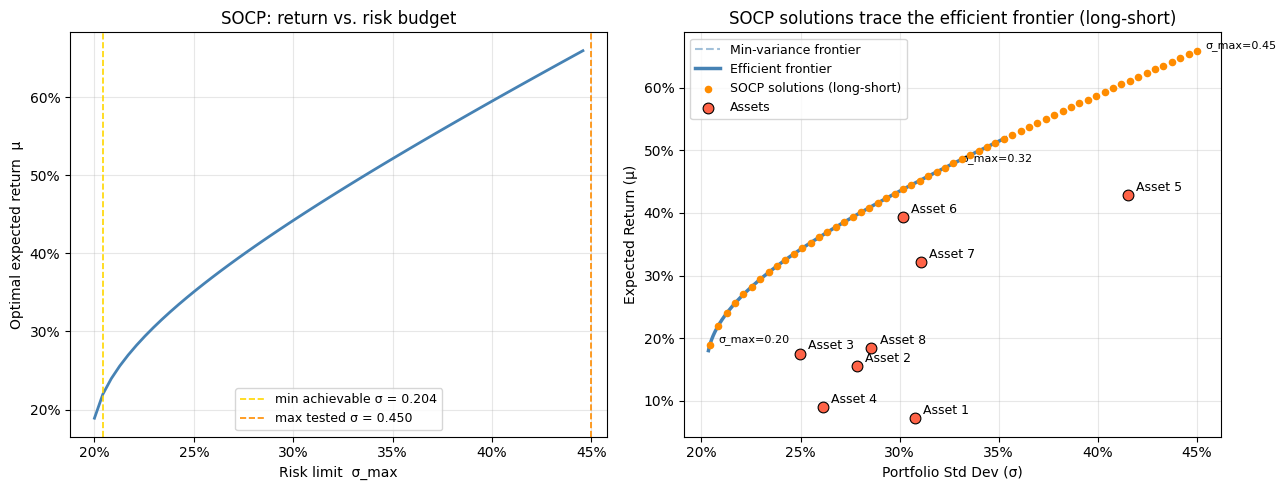

σ_max = 30%  →  weights = [-0.2092  0.0902  0.2631 -0.269   0.1364  0.6142  0.3287  0.0458]
  realized σ = 0.3000   μ = 0.4349


In [4]:
# long_only=False matches the unconstrained analytical frontier
sigma_max_grid = np.linspace(0.2, 0.45, 60)
returns, vols, weights = [], [], []

for s in sigma_max_grid:
    try:
        w = socp_max_return(mu, sigma, sigma_max=s, long_only=False)
        returns.append(float(mu @ w))
        vols.append(float(np.sqrt(w @ sigma @ w)))
        weights.append(w)
    except ValueError:
        pass

# Unconstrained min-variance frontier (analytical)
ones = np.ones(len(mu))
x = np.linalg.solve(sigma, mu)
y = np.linalg.solve(sigma, ones)
A = ones @ y;  B = ones @ x;  C = mu @ x;  D = A * C - B**2
mu_mvp = B / A
mu_grid = np.linspace(0.18, 0.52, 400)
stds = np.sqrt(np.maximum((A * mu_grid**2 - 2 * B * mu_grid + C) / D, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(sigma_max_grid[:len(returns)], returns, color="steelblue", lw=2)
ax.axvline(vols[0],  color="gold",       ls="--", lw=1.2, label=f"min achievable σ = {vols[0]:.3f}")
ax.axvline(vols[-1], color="darkorange", ls="--", lw=1.2, label=f"max tested σ = {vols[-1]:.3f}")
ax.set_xlabel("Risk limit  σ_max")
ax.set_ylabel("Optimal expected return  μ")
ax.set_title("SOCP: return vs. risk budget")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(stds, mu_grid, color="steelblue", lw=1.5, ls="--", alpha=0.5, label="Min-variance frontier")
eff = mu_grid >= mu_mvp
ax.plot(stds[eff], mu_grid[eff], color="steelblue", lw=2.5, label="Efficient frontier")
ax.scatter(vols, returns, s=20, color="darkorange", zorder=4, label="SOCP solutions (long-short)")

for idx in [0, len(returns)//2, -1]:
    ax.annotate(f"σ_max={sigma_max_grid[idx]:.2f}", (vols[idx], returns[idx]),
                textcoords="offset points", xytext=(6, 2), fontsize=8)

asset_stds = np.sqrt(np.diag(sigma))
ax.scatter(asset_stds, mu, s=60, color="tomato", edgecolors="k", lw=0.8, zorder=5, label="Assets")
for i, (s, r) in enumerate(zip(asset_stds, mu)):
    ax.annotate(f"Asset {i+1}", (s, r), textcoords="offset points", xytext=(6, 3), fontsize=9)

ax.set_xlabel("Portfolio Std Dev (σ)")
ax.set_ylabel("Expected Return (μ)")
ax.set_title("SOCP solutions trace the efficient frontier (long-short)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sample solution
w_ex = socp_max_return(mu, sigma, sigma_max=0.30, long_only=False)
print(f"σ_max = 30%  →  weights = {np.round(w_ex, 4)}")
print(f"  realized σ = {np.sqrt(w_ex @ sigma @ w_ex):.4f}   μ = {mu @ w_ex:.4f}")

And it composes. Once you're in SOCP-land, you can add *other* cone constraints in the same problem — a tracking-error cap $\|L^T(w - w_{bench})\|_2 \leq TE_{\max}$ (the volatility of the active position), or a cap on transaction-cost terms that involve norms. These are all second-order cone constraints, so the problem stays an SOCP and one solver handles all of them at once. That's why real production optimizers are built on cone solvers (MOSEK, ECOS, Clarabel) rather than pure QP solvers — the cone framework is expressive enough to hold every risk and cost constraint a real mandate imposes.

**What stays SOCP (the sweet spot — almost everything continuous).** Each of these is a second-order cone constraint, so you can stack them all in one problem and a cone solver dispatches the lot:
- Risk / volatility cap — $\|L^Tw\|_2 \leq \sigma_{\max}$, the one we just built.
- Tracking-error cap — $⁡\|L^T(w - w_b)\|_2 \leq TE_{\max}$. Same cone, applied to the *active* position $w - w_b$ against a benchmark $w_b$. This is the single most-used constraint in institutional mandates ("stay within 3% tracking error of the index"), and it's just the risk cap on the active weights.
- **Leverage / gross exposure** — $\|w\|_1 \leq L$ ($\sum|w_i| \leq L$). Technically polyhedral (even LP-representable), but it lives comfortably in the conic framework. This is your long-short gross-exposure limit.
- Turnover cap — $⁡\|w - w_0\|_1 \leq T_{\max}$, the $\ell_1$ norm of the *trade* vector from current holdings $w_0$. Limits how much you churn the book. Also polyhedral, fits the framework.
- **Robust returns under ellipsoidal uncertainty.**

SOCP is the sweet spot because it captures essentially every continuous convex constraint a real mandate imposes — risk caps, tracking error, leverage, turnover, and robustness to return uncertainty — all in one problem class that interior-point methods solve exactly and fast. That's why MOSEK, ECOS, Clarabel (and the commercial Axioma/Barra optimizers underneath) are built on cone programming, not pure QP. You stay in SOCP for the continuous mandate, step up to SDP only for matrix-valued robustness, and break to mixed-integer/metaheuristic only when the mandate has genuinely discrete features (a hard names limit, minimum lot sizes). Knowing which bucket a given constraint falls in — and therefore which solver and what guarantees you get — is exactly the solver-selection judgment this whole thread has been building.